## HW 03: Predictive Modeling of Speech

1. `a.wav` 전체에서 10차 reflection coefficient를 구하고 f10, white noise 두 입력으로 음성을 합성한다.
2. 출력과 원본을 비교하고 레포트를 작성한다.

제출 기한: 9/30 (수)

### 1. 입력 음성 확인

#### 1.1 실행 환경

In [14]:
import sys

print(sys.executable)
print("Python version:", sys.version)

/Users/yejin/Development/Yejin-02/26-Fall-Adap/.venv/bin/python
Python version: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]


#### 1.2 `a.wav` 들어 보기

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from IPython.display import Audio, display

input_path = Path("a.wav")
data, samplerate = sf.read(input_path)
assert data.ndim == 1

figure_dir = input_path.parent / "figures"
figure_dir.mkdir(exist_ok=True)

display(Audio(filename=str(input_path), normalize=False))
print(f"Data dim: {data.ndim}")
print(f"Data shape: {data.shape}")
print(f"Sample rate: {samplerate} Hz")
print(f"Data type: {data.dtype}")
print(f"Duration: {len(data) / samplerate:.2f} seconds")

Data dim: 1
Data shape: (18800,)
Sample rate: 8000 Hz
Data type: float64
Duration: 2.35 seconds


### 2. 전체 음성 모델링

#### 2.1 Levinson-Durbin algorithm

음성 전체의 자기상관 $r(k)$에서 10개의 reflection coefficient $\kappa_m$을 구한다. 자기상관을 구할 때만 전체 평균을 빼고, 모든 lag에 같은 샘플 수를 분모로 사용한다.

$$
\kappa_m=-\frac{\Delta_{m-1}}{P_{m-1}},\qquad
P_m=P_{m-1}(1-\kappa_m^2)
$$

이때 $P_m$은 $m$차 forward prediction error power이다.

In [16]:
ORDER = 10


def levinson_durbin(signal, order):
    centered = signal - np.mean(signal)
    r = np.array([
        np.dot(centered[k:], centered[:len(centered) - k]) / len(centered)
        for k in range(order + 1)
    ])

    kappa = np.zeros(order)
    a = np.array([1.0])
    P = r[0]
    if P == 0:
        return kappa, P

    for m in range(1, order + 1):
        delta = np.dot(a, r[m:0:-1])
        kappa[m - 1] = -delta / P
        a = np.r_[a, 0.0] + kappa[m - 1] * np.r_[0.0, a[::-1]]
        P *= 1 - kappa[m - 1] ** 2

    return kappa, P


kappa, P10 = levinson_durbin(data, ORDER)
print("kappa:", np.round(kappa, 3))
print(f"P10: {P10:.6g}")
print(f"Max |kappa|: {np.max(np.abs(kappa)):.4f}")

kappa: [-0.609 -0.324  0.113  0.217  0.052 -0.009 -0.107  0.225  0.146 -0.112]
P10: 0.00102244
Max |kappa|: 0.6087


#### 2.2 Lattice predictor

다음 order-update recursion으로 $f_{10}(n)$을 구한다.

$$
f_m(n)=f_{m-1}(n)+\kappa_m b_{m-1}(n-1)
$$

$$
b_m(n)=b_{m-1}(n-1)+\kappa_m f_{m-1}(n)
$$

초기값은 $f_0(n)=b_0(n)=u(n)$이다. `b_prev`에는 이전 샘플의 backward prediction error를 저장한다. 처음 호출할 때는 0으로 둔다.

In [17]:
def lattice_predictor(signal, kappa, b_prev=None):
    order = len(kappa)
    f10 = np.zeros_like(signal)
    b_prev = np.zeros(order) if b_prev is None else b_prev.copy()
    b_curr = np.empty(order)

    for n in range(len(signal)):
        f_prev = signal[n]
        b_curr[0] = signal[n]
        for m in range(order):
            delayed_b = b_prev[m]
            f_curr = f_prev + kappa[m] * delayed_b
            if m < order - 1:
                b_curr[m + 1] = delayed_b + kappa[m] * f_prev
            f_prev = f_curr
        f10[n] = f_prev
        b_prev, b_curr = b_curr, b_prev

    return f10, b_prev


def rms(signal):
    return np.sqrt(np.mean(signal ** 2))


f10, _ = lattice_predictor(data, kappa)
print(f"Input RMS: {rms(data):.5f}")
print(f"f10 RMS:   {rms(f10):.5f}")

Input RMS: 0.04618
f10 RMS:   0.03198


#### 2.3 All-pole lattice filter

차수를 10에서 0까지 내려가며 $f_0(n)$을 계산한다. 같은 계수를 사용하는 두 filter에 각각 $f_{10}(n)$과 white noise를 넣는다.

$$
f_{m-1}(n)=f_m(n)-\kappa_m b_{m-1}(n-1)
$$

In [18]:
def all_pole_lattice(excitation, kappa, b_prev=None):
    order = len(kappa)
    f0 = np.zeros_like(excitation)
    f_stage = np.empty(order + 1)
    b_prev = np.zeros(order) if b_prev is None else b_prev.copy()
    b_curr = np.empty(order)

    for n in range(len(excitation)):
        f_stage[order] = excitation[n]
        for m in range(order, 0, -1):
            f_stage[m - 1] = f_stage[m] - kappa[m - 1] * b_prev[m - 1]
        f0[n] = f_stage[0]
        b_curr[0] = f_stage[0]
        for m in range(1, order):
            b_curr[m] = b_prev[m - 1] + kappa[m - 1] * f_stage[m - 1]
        b_prev, b_curr = b_curr, b_prev

    return f0, b_prev


syn_f10, _ = all_pole_lattice(f10, kappa)
unit_noise = np.random.default_rng(3).standard_normal(len(data))
white_noise = unit_noise * np.sqrt(P10)
syn_noise, _ = all_pole_lattice(white_noise, kappa)

print(f"Max reconstruction error: {np.max(np.abs(data - syn_f10)):.3e}")
print(f"White noise RMS: {rms(white_noise):.5f}")

Max reconstruction error: 1.110e-16
White noise RMS: 0.03184


#### 2.4 출력 파일 저장

In [19]:
def save_output(name, signal):
    assert np.all(np.isfinite(signal))
    assert np.max(np.abs(signal)) < 1, "PCM 저장 전에 peak를 확인해야 한다."
    path = input_path.with_name(name)
    sf.write(path, signal, samplerate, subtype="PCM_16")
    saved, fs = sf.read(path)
    assert fs == samplerate and saved.shape == data.shape
    return saved


saved_f10 = save_output("syn_f10.wav", syn_f10)
saved_noise = save_output("syn_noise.wav", syn_noise)
for name in ["a.wav", "syn_f10.wav", "syn_noise.wav"]:
    print(name)
    display(Audio(filename=str(input_path.with_name(name)), normalize=False))

a.wav


syn_f10.wav


syn_noise.wav


### 3. 결과와 한계

#### 3.1 역필터 동작 확인

$f_{10}(n)$을 넣었을 때 원본이 복원되는 것은 predictor와 합성기가 역관계이기 때문이다. 같은 계수와 초기 상태를 사용하면 다음 관계가 성립한다.

$$
F_{10}(z)=A(z)U(z),\qquad \hat U(z)=\frac{F_{10}(z)}{A(z)}=U(z)
$$

따라서 완전 복원만으로 모델이 음성의 특성을 잘 표현한다고 판단할 수는 없다.

In [20]:
from scipy.linalg import solve_toeplitz
from scipy.signal import lfilter

centered = data - np.mean(data)
r = np.array([
    np.dot(centered[k:], centered[:len(data) - k]) / len(data)
    for k in range(ORDER + 1)
])
w_f = solve_toeplitz(r[:-1], r[1:])
a_direct = np.r_[1.0, -w_f]
f10_direct = lfilter(a_direct, [1.0], data)
noise_direct = lfilter([1.0], a_direct, white_noise)

print(f"Predictor difference: {np.max(np.abs(f10 - f10_direct)):.3e}")
print(f"Synthesis difference: {np.max(np.abs(syn_noise - noise_direct)):.3e}")
print("Saved f10 sample-exact:", np.array_equal(data, saved_f10))
assert np.allclose(f10, f10_direct, atol=1e-12, rtol=0)
assert np.allclose(syn_noise, noise_direct, atol=1e-12, rtol=0)

Predictor difference: 1.665e-16
Synthesis difference: 1.110e-16
Saved f10 sample-exact: True


#### 3.2 시간-주파수 도메인 비교

256-sample Hann window와 75% overlap으로 STFT를 계산한다.

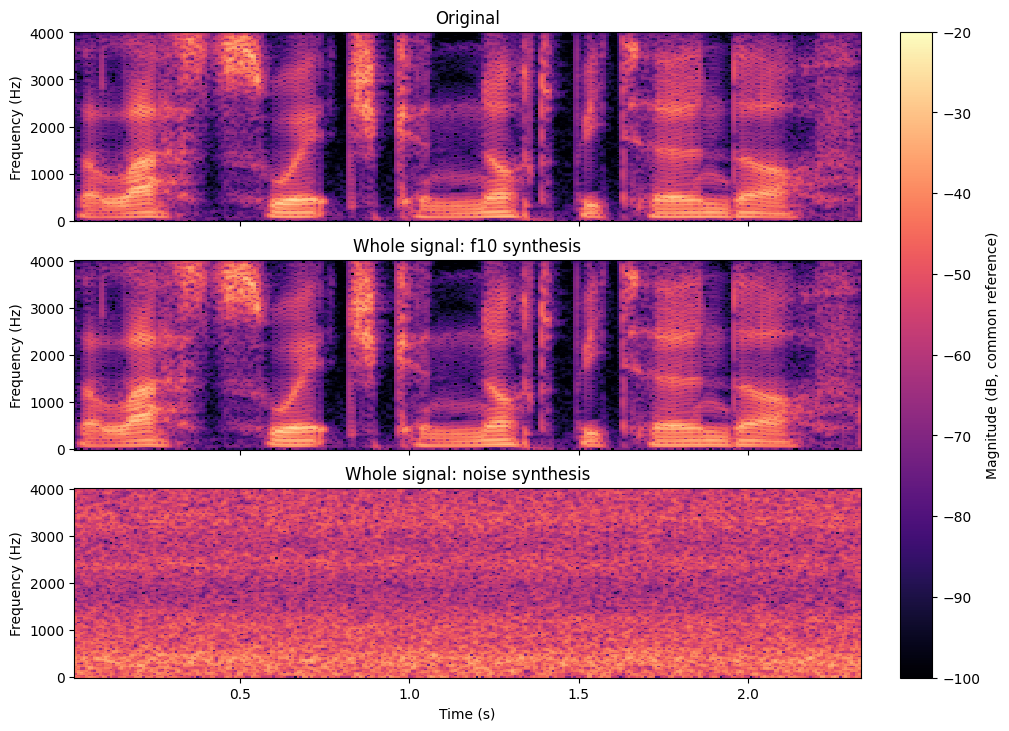

In [21]:
from scipy.signal import stft


def plot_spectrograms(signals, filename):
    fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.4 * len(signals)),
                             sharex=True, sharey=True, constrained_layout=True)
    for ax, (name, signal) in zip(axes, signals.items()):
        freq, time, spectrum = stft(
            signal, fs=samplerate, window="hann", nperseg=256,
            noverlap=192, boundary=None, padded=False,
        )
        spec_db = 20 * np.log10(np.maximum(np.abs(spectrum), 1e-10))
        mesh = ax.pcolormesh(time, freq, spec_db, shading="auto",
                             cmap="magma", vmin=-100, vmax=-20)
        ax.set_title(name)
        ax.set_ylabel("Frequency (Hz)")
    axes[-1].set_xlabel("Time (s)")
    fig.colorbar(mesh, ax=axes, label="Magnitude (dB, common reference)")
    fig.savefig(figure_dir / filename, dpi=160)
    plt.show()


plot_spectrograms({
    "Original": data,
    "Whole signal: f10 synthesis": saved_f10,
    "Whole signal: noise synthesis": saved_noise,
}, "whole_spectrogram.png")

#### 3.3 전체 모델만으로 충분한가?

`f10` 출력은 원본과 샘플이 일치하지만, 잡음 출력은 청취했을 때 말소리가 구별되지 않는 잡음처럼 들렸다. Spectrogram에서도 발화에 따른 변화가 사라지고 비슷한 주파수 분포가 계속 이어진다.

이는 합성기가 동작하지 않아서 생긴 결과는 아니다. 고정된 filter는 잡음에 전체 음성의 평균적인 주파수 특성을 부여하지만, 발음에 따라 달라지는 포먼트와 에너지 변화를 표현하지 못한다.

따라서 **잡음 입력에서도 시간에 따라 변하는 음성 특성을 반영하려면 짧은 구간마다 모델을 다시 구할 필요가 있다.** 다음 실험에서는 청크별로 $\kappa_m$과 $P_{10}$을 추정한다.

### 4. 청크별 음성 모델링

#### 4.1 20 ms 구간별 계수와 error power

청크는 20 ms 길이를 사용한다. 현재 sample rate에서는 160 samples이며, 마지막 청크는 남은 80 samples를 사용한다. 청크끼리 겹치지 않고, 별도의 window를 곱하지 않는다.

In [22]:
CHUNK_SIZE = round(0.02 * samplerate)
chunk_starts = np.arange(0, len(data), CHUNK_SIZE)
chunk_kappas = []
chunk_powers = []

for start in chunk_starts:
    signal = data[start:start + CHUNK_SIZE]
    kappa_chunk, P10_chunk = levinson_durbin(signal, ORDER)
    chunk_kappas.append(kappa_chunk)
    chunk_powers.append(P10_chunk)

chunk_kappas = np.array(chunk_kappas)
chunk_powers = np.array(chunk_powers)
assert np.all(np.abs(chunk_kappas) < 1)
assert np.all(chunk_powers >= 0)

print(f"Chunk size: {CHUNK_SIZE} samples")
print(f"Number of chunks: {len(chunk_starts)}")
print(f"Last chunk: {len(data) - chunk_starts[-1]} samples")
print(f"Max |kappa|: {np.max(np.abs(chunk_kappas)):.4f}")

Chunk size: 160 samples
Number of chunks: 118
Last chunk: 80 samples
Max |kappa|: 0.9790


#### 4.2 청크별 분석과 합성

각 filter의 지연 상태를 다음 청크로 이어 준다. Predictor, $f_{10}$ 합성기, 잡음 합성기의 상태는 각각 따로 저장한다.

In [23]:
f10_chunk = np.zeros_like(data)
syn_f10_chunk = np.zeros_like(data)
white_noise_chunk = np.zeros_like(data)
syn_noise_chunk = np.zeros_like(data)
syn_noise_kappa_only = np.zeros_like(data)

b_analysis = None
b_f10 = None
b_noise = None
b_kappa_only = None

for i, start in enumerate(chunk_starts):
    end = min(start + CHUNK_SIZE, len(data))
    kappa_i = chunk_kappas[i]
    f10_chunk[start:end], b_analysis = lattice_predictor(
        data[start:end], kappa_i, b_analysis,
    )
    syn_f10_chunk[start:end], b_f10 = all_pole_lattice(
        f10_chunk[start:end], kappa_i, b_f10,
    )
    white_noise_chunk[start:end] = unit_noise[start:end] * np.sqrt(chunk_powers[i])
    syn_noise_chunk[start:end], b_noise = all_pole_lattice(
        white_noise_chunk[start:end], kappa_i, b_noise,
    )
    syn_noise_kappa_only[start:end], b_kappa_only = all_pole_lattice(
        white_noise[start:end], kappa_i, b_kappa_only,
    )

print(f"Chunk f10 RMS: {rms(f10_chunk):.5f}")
print(f"Max reconstruction error: {np.max(np.abs(data - syn_f10_chunk)):.3e}")
assert np.allclose(data, syn_f10_chunk, atol=1e-12, rtol=0)

saved_f10_chunk = save_output("syn_f10_chunk.wav", syn_f10_chunk)
saved_noise_chunk = save_output("syn_noise_chunk.wav", syn_noise_chunk)
print("Saved chunk f10 sample-exact:", np.array_equal(data, saved_f10_chunk))
for name in ["syn_f10_chunk.wav", "syn_noise_chunk.wav"]:
    print(name)
    display(Audio(filename=str(input_path.with_name(name)), normalize=False))

Chunk f10 RMS: 0.01622
Max reconstruction error: 2.220e-16
Saved chunk f10 sample-exact: True
syn_f10_chunk.wav


syn_noise_chunk.wav


### 5. 청크별 결과와 전체 모델 비교

#### 5.1 Spectrogram 비교

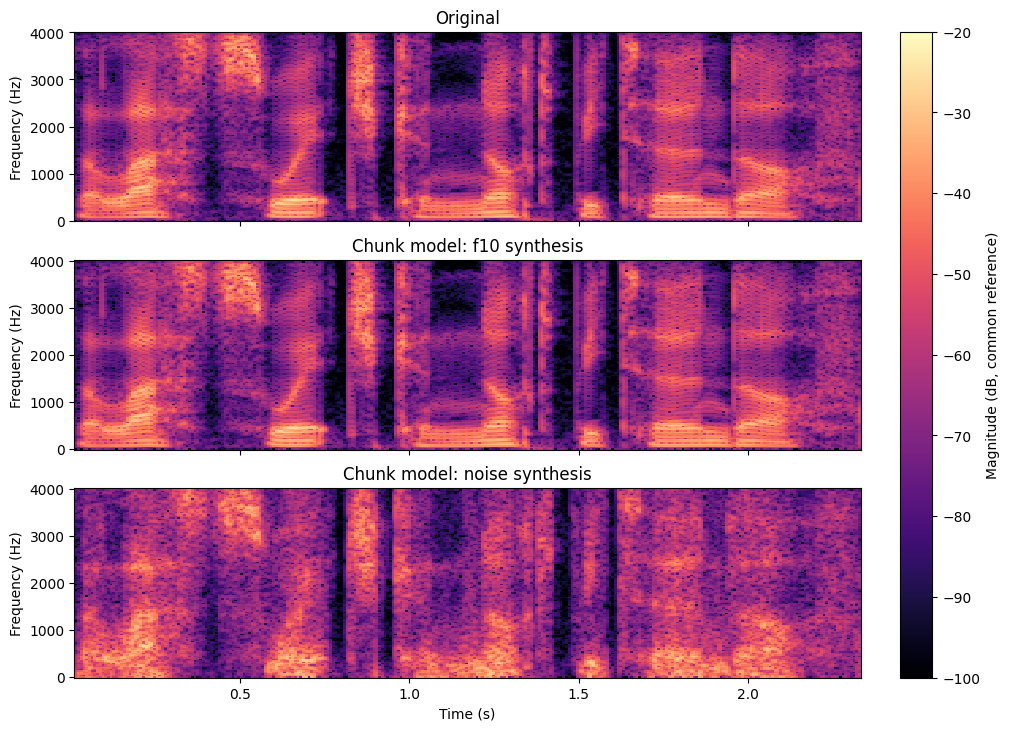

In [24]:
plot_spectrograms({
    "Original": data,
    "Chunk model: f10 synthesis": saved_f10_chunk,
    "Chunk model: noise synthesis": saved_noise_chunk,
}, "chunk_spectrogram.png")

#### 5.2 구간별 에너지와 잡음 출력 비교

Original          RMS=0.04618  peak=0.59949  RMS CV=0.748  envelope corr=1.000
Whole f10         RMS=0.04618  peak=0.59949  RMS CV=0.748  envelope corr=1.000
Whole noise       RMS=0.04609  peak=0.17542  RMS CV=0.101  envelope corr=-0.024
Chunk f10         RMS=0.04618  peak=0.59949  RMS CV=0.748  envelope corr=1.000
Chunk noise       RMS=0.04499  peak=0.32040  RMS CV=0.744  envelope corr=0.963
Chunk kappa only  RMS=0.11467  peak=0.94283  RMS CV=0.663  envelope corr=0.214


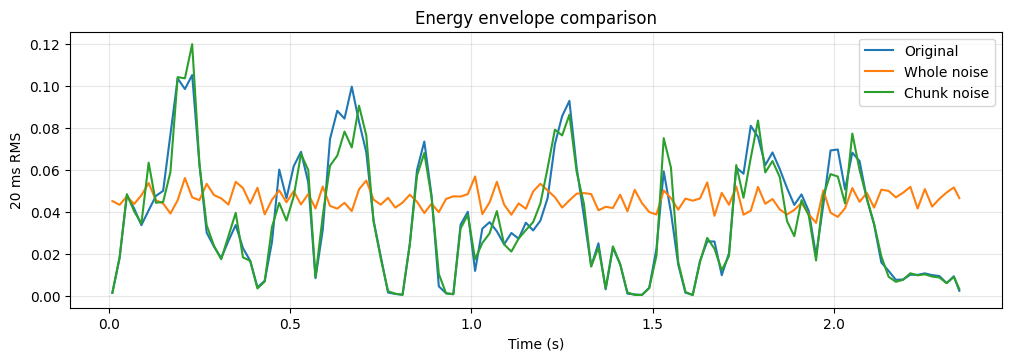

In [25]:
def chunkwise_rms(signal):
    return np.array([rms(signal[start:start + CHUNK_SIZE]) for start in chunk_starts])


comparison_signals = {
    "Original": data,
    "Whole f10": saved_f10,
    "Whole noise": saved_noise,
    "Chunk f10": saved_f10_chunk,
    "Chunk noise": saved_noise_chunk,
    "Chunk kappa only": syn_noise_kappa_only,
}
reference_envelope = chunkwise_rms(data)
metrics = {}
for name, signal in comparison_signals.items():
    envelope = chunkwise_rms(signal)
    metrics[name] = {
        "rms": float(rms(signal)),
        "peak": float(np.max(np.abs(signal))),
        "rms_cv": float(np.std(envelope) / np.mean(envelope)),
        "envelope_corr": float(np.corrcoef(reference_envelope, envelope)[0, 1]),
    }
    m = metrics[name]
    print(f"{name:17s} RMS={m['rms']:.5f}  peak={m['peak']:.5f}  "
          f"RMS CV={m['rms_cv']:.3f}  envelope corr={m['envelope_corr']:.3f}")

chunk_ends = np.minimum(chunk_starts + CHUNK_SIZE, len(data))
time_sec = (chunk_starts + chunk_ends) / (2 * samplerate)
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
for name in ["Original", "Whole noise", "Chunk noise"]:
    ax.plot(time_sec, chunkwise_rms(comparison_signals[name]), label=name)
ax.set_xlabel("Time (s)")
ax.set_ylabel("20 ms RMS")
ax.set_title("Energy envelope comparison")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig(figure_dir / "rms_comparison.png", dpi=160)
plt.show()

#### 5.3 같은 재생 레벨에서 들어 보기

In [26]:
for name in ["Original", "Whole noise", "Chunk kappa only", "Chunk noise"]:
    signal = comparison_signals[name]
    playback = signal * (rms(data) / rms(signal))
    assert np.max(np.abs(playback)) < 1
    print(name)
    display(Audio(data=playback, rate=samplerate, normalize=False))

Original


Whole noise


Chunk kappa only


Chunk noise


### 6. 비교 정리

- 전체 모델과 청크별 모델 모두 $f_{10}(n)$을 입력하면 원본을 복원한다.
- 전체 모델의 잡음 출력에서는 발화에 따른 변화가 잘 나타나지 않았다. 청크별 모델에서는 계수와 error power가 바뀌므로 시간에 따른 주파수 분포와 에너지 변화가 출력에 반영된다.
- 청크별 잡음 출력의 20 ms RMS 상관계수는 원본 대비 0.963으로, 전체 모델의 -0.024보다 높았다. Spectrogram에서도 발화에 따른 주파수 분포와 에너지 변화가 나타났다.
- 청크별 잡음 합성에는 원래 excitation의 피치 주기성이 없다. 따라서 원본 화자의 목소리와 완전히 같은 결과를 기대할 수는 없다. 그러나 같은 문장을 속삭이며 말하는 듯이 들려 단어 식별이 가능했다.
- 전체 모델링과 청크별 모델링에서 잡음 출력의 개선은 청크별 계수와 청크별 입력 세기의 영향을 함께 받는다. 계수만 바꾼 중간 결과를 통해 이를 확인했다.